In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
dataset_path = "/content/drive/MyDrive/Glaucoma_dataset"

In [3]:
import os

dataset_path = "/content/drive/MyDrive/Glaucoma_dataset"

for root, dirs, files in os.walk(dataset_path):
    print(root)

/content/drive/MyDrive/Glaucoma_dataset
/content/drive/MyDrive/Glaucoma_dataset/train
/content/drive/MyDrive/Glaucoma_dataset/train/glaucoma
/content/drive/MyDrive/Glaucoma_dataset/train/normal
/content/drive/MyDrive/Glaucoma_dataset/test
/content/drive/MyDrive/Glaucoma_dataset/test/glaucoma
/content/drive/MyDrive/Glaucoma_dataset/test/normal
/content/drive/MyDrive/Glaucoma_dataset/val
/content/drive/MyDrive/Glaucoma_dataset/val/normal
/content/drive/MyDrive/Glaucoma_dataset/val/glaucoma


In [4]:
import os

dataset_path = "/content/drive/MyDrive/Glaucoma_dataset"

for split in ["train", "val", "test"]:
    print(f"\n{'='*30}")
    print(split.upper())
    print('='*30)

    for cls in ["glaucoma", "normal"]:
        folder = os.path.join(dataset_path, split, cls)

        count = len([
            f for f in os.listdir(folder)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])

        print(f"{cls}: {count}")


TRAIN
glaucoma: 4000
normal: 4000

VAL
glaucoma: 385
normal: 385

TEST
glaucoma: 385
normal: 385


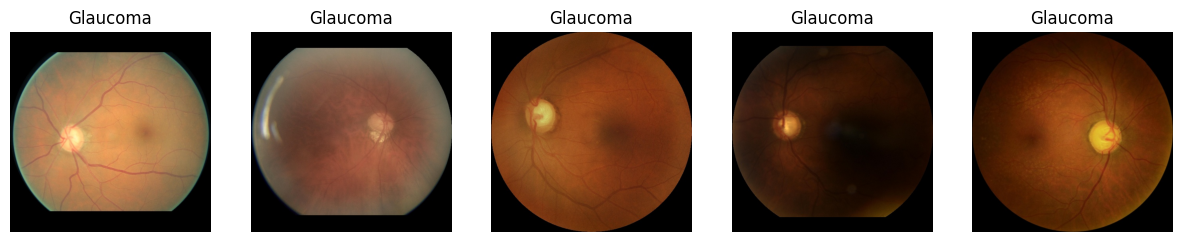

In [5]:
import os
import matplotlib.pyplot as plt
from PIL import Image

dataset_path = "/content/drive/MyDrive/Glaucoma_dataset"

glaucoma_folder = os.path.join(dataset_path, "train", "glaucoma")

images = os.listdir(glaucoma_folder)[:5]

plt.figure(figsize=(15,5))

for i, img_name in enumerate(images):
    img = Image.open(os.path.join(glaucoma_folder, img_name))

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.title("Glaucoma")
    plt.axis("off")

plt.show()

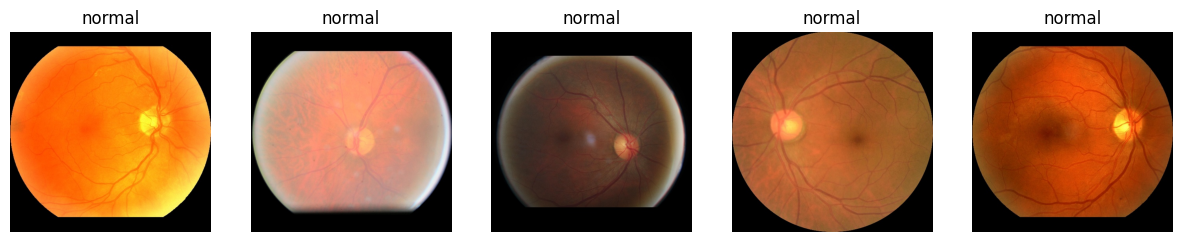

In [6]:
import os
import matplotlib.pyplot as plt
from PIL import Image

dataset_path = "/content/drive/MyDrive/Glaucoma_dataset"

glaucoma_folder = os.path.join(dataset_path, "train", "normal")

images = os.listdir(glaucoma_folder)[:5]

plt.figure(figsize=(15,5))

for i, img_name in enumerate(images):
    img = Image.open(os.path.join(glaucoma_folder, img_name))

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.title("normal")
    plt.axis("off")

plt.show()

In [7]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

In [9]:
dataset_path = "/content/drive/MyDrive/Glaucoma_dataset"


In [10]:
widths = []
heights = []

for split in ["train","val","test"]:
    for cls in ["glaucoma","normal"]:

        folder = os.path.join(dataset_path, split, cls)

        for file in tqdm(os.listdir(folder)):

            path = os.path.join(folder,file)

            try:
                img = Image.open(path)

                w,h = img.size

                widths.append(w)
                heights.append(h)

            except:
                pass

print("Total Images:", len(widths))

print("Min Width:", min(widths))
print("Max Width:", max(widths))

print("Min Height:", min(heights))
print("Max Height:", max(heights))

print("Average Width:", np.mean(widths))
print("Average Height:", np.mean(heights))

100%|██████████| 385/385 [00:05<00:00, 68.97it/s] 

Total Images: 9540
Min Width: 512
Max Width: 512
Min Height: 512
Max Height: 512
Average Width: 512.0
Average Height: 512.0


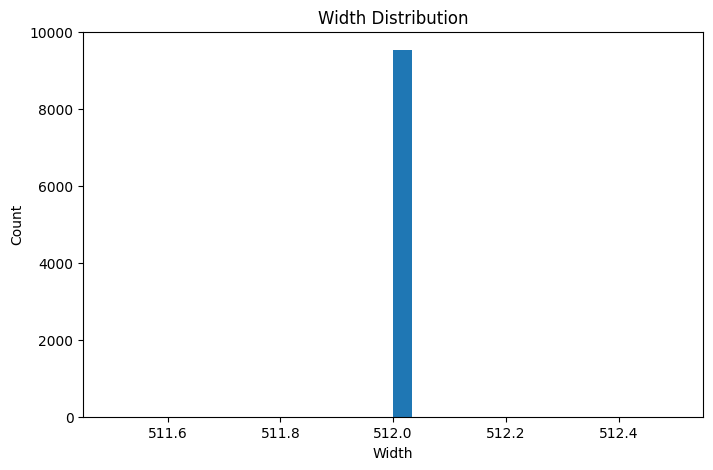

In [11]:
plt.figure(figsize=(8,5))

plt.hist(widths,bins=30)
plt.title("Width Distribution")
plt.xlabel("Width")
plt.ylabel("Count")

plt.show()

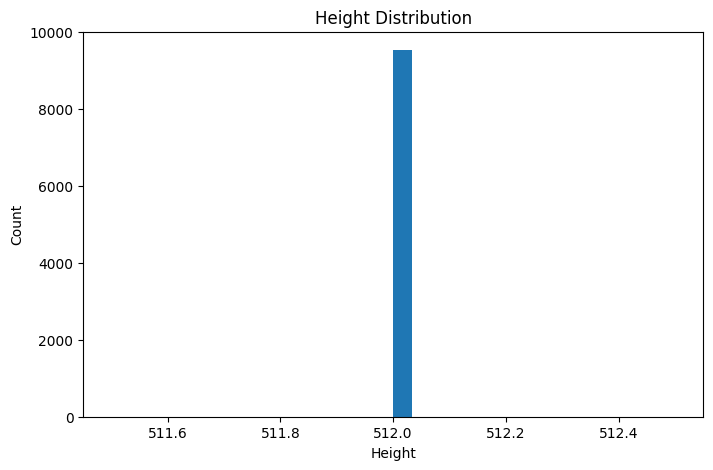

In [12]:
plt.figure(figsize=(8,5))

plt.hist(heights,bins=30)

plt.title("Height Distribution")
plt.xlabel("Height")
plt.ylabel("Count")

plt.show()

In [13]:
brightness = []

for split in ["train","val","test"]:
    for cls in ["glaucoma","normal"]:

        folder = os.path.join(dataset_path, split, cls)

        for file in tqdm(os.listdir(folder)):

            path = os.path.join(folder,file)

            try:
                img = cv2.imread(path)

                gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

                brightness.append(np.mean(gray))

            except:
                pass

print("Average Brightness:", np.mean(brightness))

100%|██████████| 385/385 [00:03<00:00, 111.99it/s]

Average Brightness: 65.39229380929496


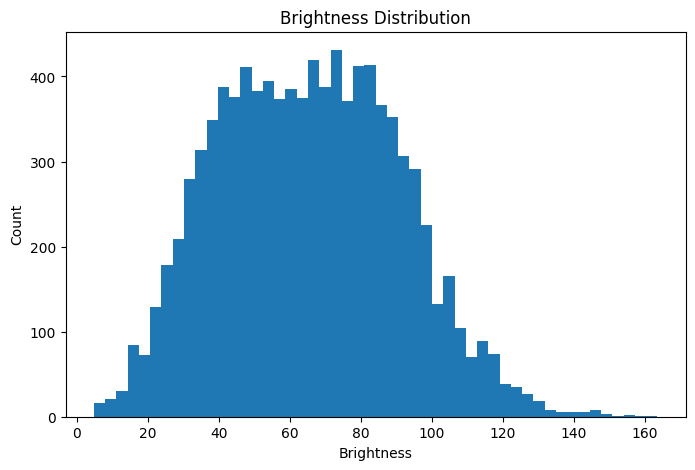

In [14]:
plt.figure(figsize=(8,5))

plt.hist(brightness,bins=50)

plt.title("Brightness Distribution")
plt.xlabel("Brightness")
plt.ylabel("Count")

plt.show()

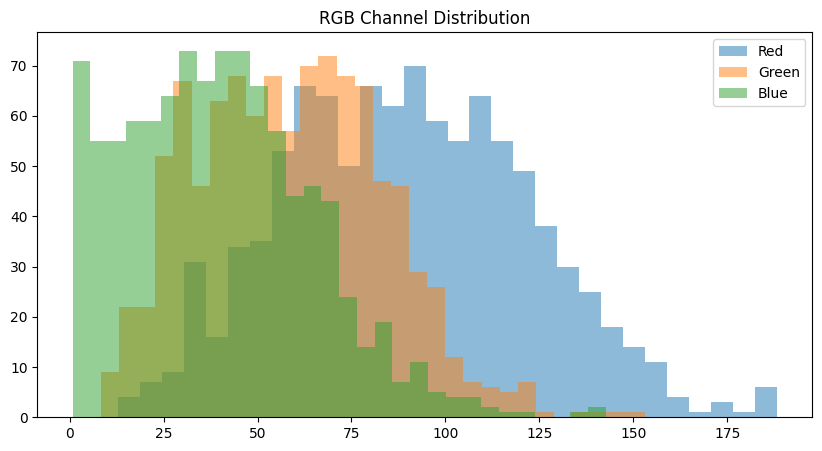

In [15]:
r_vals = []
g_vals = []
b_vals = []

sample_count = 1000

counter = 0

for split in ["train"]:
    for cls in ["glaucoma","normal"]:

        folder = os.path.join(dataset_path, split, cls)

        for file in os.listdir(folder):

            if counter >= sample_count:
                break

            path = os.path.join(folder,file)

            img = cv2.imread(path)

            img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

            r_vals.append(np.mean(img[:,:,0]))
            g_vals.append(np.mean(img[:,:,1]))
            b_vals.append(np.mean(img[:,:,2]))

            counter += 1

plt.figure(figsize=(10,5))

plt.hist(r_vals,bins=30,alpha=0.5,label='Red')
plt.hist(g_vals,bins=30,alpha=0.5,label='Green')
plt.hist(b_vals,bins=30,alpha=0.5,label='Blue')

plt.legend()
plt.title("RGB Channel Distribution")

plt.show()

In [16]:
blur_scores = []

for split in ["train","val","test"]:
    for cls in ["glaucoma","normal"]:

        folder = os.path.join(dataset_path, split, cls)

        for file in tqdm(os.listdir(folder)):

            path = os.path.join(folder,file)

            try:

                img = cv2.imread(path)

                gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

                score = cv2.Laplacian(gray,cv2.CV_64F).var()

                blur_scores.append(score)

            except:
                pass

print("Average Blur Score:", np.mean(blur_scores))

100%|██████████| 385/385 [00:04<00:00, 85.42it/s] 

Average Blur Score: 161.5599760141089


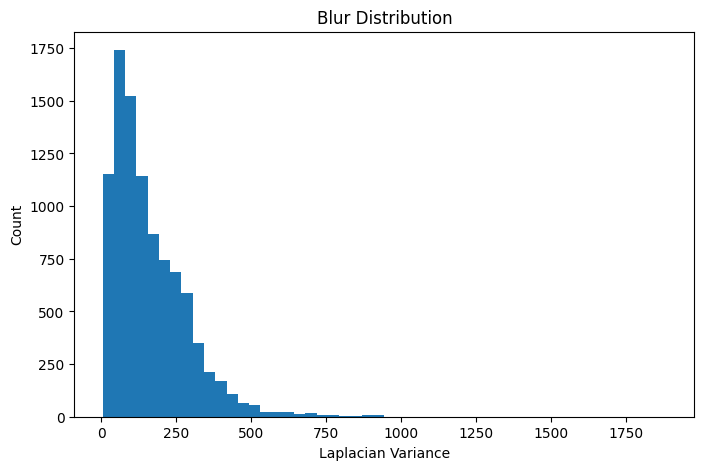

In [17]:
plt.figure(figsize=(8,5))

plt.hist(blur_scores,bins=50)

plt.title("Blur Distribution")

plt.xlabel("Laplacian Variance")
plt.ylabel("Count")

plt.show()

In [18]:
bad_images = []

for split in ["train","val","test"]:
    for cls in ["glaucoma","normal"]:

        folder = os.path.join(dataset_path, split, cls)

        for file in os.listdir(folder):

            path = os.path.join(folder,file)

            try:
                Image.open(path).verify()

            except:
                bad_images.append(path)

print("Corrupted Images:", len(bad_images))

Corrupted Images: 0


In [19]:
!pip install -q tensorflow

In [20]:
import tensorflow as tf
import os

from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)

In [22]:
DATASET_PATH = "/content/drive/MyDrive/Glaucoma_dataset"

IMG_SIZE = (384, 384)

BATCH_SIZE = 16

SEED = 42

In [23]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_PATH, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_PATH, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_PATH, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

Found 8000 files belonging to 2 classes.
Found 770 files belonging to 2 classes.
Found 770 files belonging to 2 classes.


In [27]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_PATH, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True,
    seed=SEED
)

print(train_ds.class_names)

Found 8000 files belonging to 2 classes.
['glaucoma', 'normal']


In [28]:
print(train_ds.class_names)

['glaucoma', 'normal']


In [43]:
base_model = tf.keras.applications.ConvNeXtTiny(
    include_top=False,
    weights="imagenet",
    input_shape=(384, 384, 3)
)

base_model.trainable = True

In [54]:
inputs = tf.keras.Input(shape=(384,384,3))

x = tf.keras.applications.convnext.preprocess_input(inputs)

x = base_model(x, training=False)

In [55]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

print("Total Layers:", len(base_model.layers))
print(
    "Trainable Layers:",
    sum(layer.trainable for layer in base_model.layers)
)

Total Layers: 133
Trainable Layers: 30


In [56]:
inputs = tf.keras.Input(shape=(384,384,3))

x = tf.keras.applications.convnext.preprocess_input(inputs)

x = base_model(inputs, training=True)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.4)(x)

x = layers.Dense(
    256,
    activation="relu"
)(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    1,
    activation="sigmoid"
)(x)

model = tf.keras.Model(
    inputs,
    outputs
)

In [57]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),

    loss="binary_crossentropy",

    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)

In [58]:
model.summary()

Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_24 (InputLayer)     │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convnext_tiny (Functional)      │ (None, 12, 12, 768)    │    27,820,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 768)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,017,249 (106.88 MB)

 Trainable params: 16,871,169 (64.36 MB)

 Non-trainable params: 11,146,080 (42.52 MB)

In [59]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_convnext_finetuned.keras",
    monitor="val_auc",
    mode="max",
    save_best_only=True,
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=5,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    verbose=1
)

In [60]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[
        checkpoint,
        early_stop,
        reduce_lr
    ]
)

Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.5879 - auc: 0.6217 - loss: 0.6805
Epoch 1: val_auc improved from None to 0.86291, saving model to best_convnext_finetuned.keras

Epoch 1: finished saving model to best_convnext_finetuned.keras
500/500 ━━━━━━━━━━━━━━━━━━━━ 255s 447ms/step - accuracy: 0.6474 - auc: 0.7060 - loss: 0.6246 - val_accuracy: 0.7857 - val_auc: 0.8629 - val_loss: 0.4839 - learning_rate: 1.0000e-05
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.7779 - auc: 0.8540 - loss: 0.4808
Epoch 2: val_auc improved from 0.86291 to 0.91500, saving model to best_convnext_finetuned.keras

Epoch 2: finished saving model to best_convnext_finetuned.keras
500/500 ━━━━━━━━━━━━━━━━━━━━ 215s 429ms/step - accuracy: 0.7954 - auc: 0.8711 - loss: 0.4532 - val_accuracy: 0.8429 - val_auc: 0.9150 - val_loss: 0.3779 - learning_rate: 1.0000e-05
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.8357 - auc: 0.9103 - loss: 0.3806
Epoch 3: va

In [61]:
import tensorflow as tf

best_model = tf.keras.models.load_model(
    "best_convnext_finetuned.keras"
)

In [62]:
test_loss, test_acc, test_auc = best_model.evaluate(test_ds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test AUC: {test_auc:.4f}")

49/49 ━━━━━━━━━━━━━━━━━━━━ 20s 279ms/step - accuracy: 0.8935 - auc: 0.9529 - loss: 0.3155
Test Loss: 0.3155
Test Accuracy: 0.8935
Test AUC: 0.9529


In [63]:
import numpy as np

y_true = []
y_pred = []
y_prob = []

for images, labels in test_ds:

    preds = best_model.predict(images, verbose=0)

    y_true.extend(labels.numpy())

    y_prob.extend(preds.flatten())

    y_pred.extend((preds > 0.5).astype(int).flatten())

y_true = np.array(y_true).astype(int)
y_pred = np.array(y_pred).astype(int)
y_prob = np.array(y_prob)

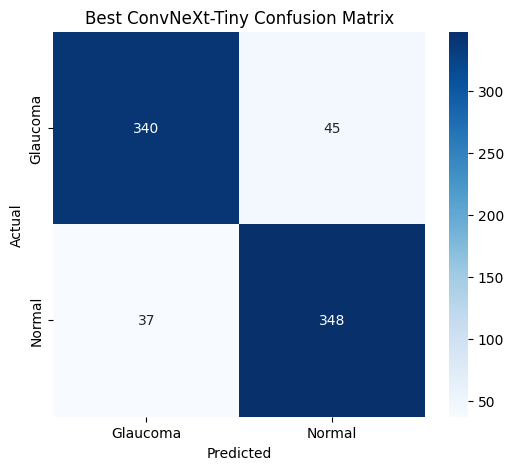

In [64]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Glaucoma","Normal"],
    yticklabels=["Glaucoma","Normal"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Best ConvNeXt-Tiny Confusion Matrix")

plt.show()

In [65]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["glaucoma","normal"]
    )
)

              precision    recall  f1-score   support

    glaucoma       0.90      0.88      0.89       385
      normal       0.89      0.90      0.89       385

    accuracy                           0.89       770
   macro avg       0.89      0.89      0.89       770
weighted avg       0.89      0.89      0.89       770



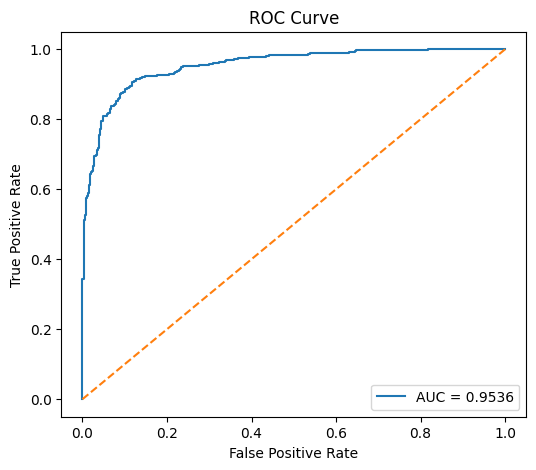

In [66]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_true, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [67]:
results = {
    "Test Accuracy": test_acc,
    "Test AUC": test_auc
}

print(results)

{'Test Accuracy': 0.8935064673423767, 'Test AUC': 0.9528553485870361}


In [87]:
best_model.layers[1].summary()

Model: "convnext_tiny"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_16      │ (None, 384, 384,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_pres… │ (None, 384, 384,  │          0 │ input_layer_16[0… │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stem  │ (None, 96, 96,    │      4,896 │ convnext_tiny_pr… │
│ (Sequential)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 96, 96,    │      4,800 │ convnext_tiny_st… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 96, 96,    │        192 │ convnext_tiny_st… │
│ (LayerNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 96, 96,    │     37,248 │ convnext_tiny_st… │
│ (Dense)             │ 384)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 96, 96,    │          0 │ convnext_tiny_st… │
│ (Activation)        │ 384)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 96, 96,    │     36,960 │ convnext_tiny_st… │
│ (Dense)             │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 96, 96,    │         96 │ convnext_tiny_st… │
│ (LayerScale)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 96, 96,    │          0 │ convnext_tiny_st… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_54 (Add)        │ (None, 96, 96,    │          0 │ convnext_tiny_st… │
│                     │ 96)               │            │ convnext_tiny_st… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 96, 96,    │      4,800 │ add_54[0][0]      │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 96, 96,    │        192 │ convnext_tiny_st… │
│ (LayerNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 96, 96,    │     37,248 │ convnext_tiny_st… │
│ (Dense)             │ 384)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 96, 96,    │          0 │ convnext_tiny_st… │
│ (Activation)        │ 384)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 96, 96,    │     36,960 │ convnext_tiny_st… │
│ (Dense)             │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, 96, 96,    │         96 │ convnext_tiny_st

 Total params: 27,820,128 (106.13 MB)

 Trainable params: 16,674,048 (63.61 MB)

 Non-trainable params: 11,146,080 (42.52 MB)

In [88]:
convnext = best_model.layers[1]

print(convnext.input)
print(convnext.output)

<KerasTensor shape=(None, 384, 384, 3), dtype=float32, sparse=False, ragged=False, name=input_layer_16>
<KerasTensor shape=(None, 12, 12, 768), dtype=float32, sparse=False, ragged=False, name=keras_tensor_1689>


In [90]:
convnext = best_model.get_layer("convnext_tiny")

for layer in convnext.layers[-20:]:
    print(layer.name, layer.output.shape)

convnext_tiny_stage_3_block_0_pointwise_conv_1 (None, 12, 12, 3072)
convnext_tiny_stage_3_block_0_gelu (None, 12, 12, 3072)
convnext_tiny_stage_3_block_0_pointwise_conv_2 (None, 12, 12, 768)
convnext_tiny_stage_3_block_0_layer_scale (None, 12, 12, 768)
convnext_tiny_stage_3_block_0_identity (None, 12, 12, 768)
convnext_tiny_stage_3_block_1_depthwise_conv (None, 12, 12, 768)
convnext_tiny_stage_3_block_1_layernorm (None, 12, 12, 768)
convnext_tiny_stage_3_block_1_pointwise_conv_1 (None, 12, 12, 3072)
convnext_tiny_stage_3_block_1_gelu (None, 12, 12, 3072)
convnext_tiny_stage_3_block_1_pointwise_conv_2 (None, 12, 12, 768)
convnext_tiny_stage_3_block_1_layer_scale (None, 12, 12, 768)
convnext_tiny_stage_3_block_1_identity (None, 12, 12, 768)
convnext_tiny_stage_3_block_2_depthwise_conv (None, 12, 12, 768)
convnext_tiny_stage_3_block_2_layernorm (None, 12, 12, 768)
convnext_tiny_stage_3_block_2_pointwise_conv_1 (None, 12, 12, 3072)
convnext_tiny_stage_3_block_2_gelu (None, 12, 12, 3072)
co

In [91]:
last_conv_layer_name = "convnext_tiny_stage_3_block_2_identity"

In [92]:
convnext = best_model.get_layer("convnext_tiny")

last_conv_layer = convnext.get_layer(
    "convnext_tiny_stage_3_block_2_identity"
)

grad_model = tf.keras.models.Model(
    inputs=convnext.input,
    outputs=[
        last_conv_layer.output,
        convnext.output
    ]
)

print("Grad Model Ready")

Grad Model Ready


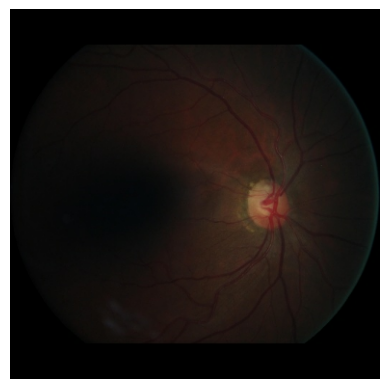

In [93]:
for images, labels in test_ds.take(1):
    img = images[0]
    label = labels[0]
    break

plt.imshow(img.numpy().astype("uint8"))
plt.axis("off")
plt.show()

In [94]:
import tensorflow as tf
import numpy as np

def make_gradcam_heatmap(img_array):

    with tf.GradientTape() as tape:

        feature_maps, predictions = grad_model(img_array)

        score = tf.reduce_mean(predictions)

    grads = tape.gradient(
        score,
        feature_maps
    )

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0,1,2)
    )

    feature_maps = feature_maps[0]

    heatmap = tf.reduce_sum(
        pooled_grads * feature_maps,
        axis=-1
    )

    heatmap = tf.maximum(
        heatmap,
        0
    )

    heatmap = heatmap / (
        tf.reduce_max(heatmap) + 1e-8
    )

    return heatmap.numpy()

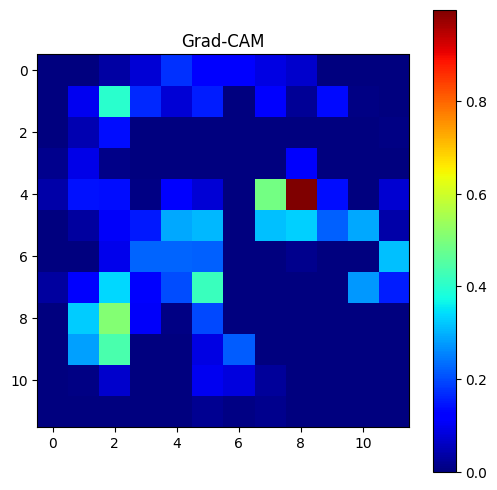

In [95]:
img_array = tf.expand_dims(
    img,
    axis=0
)

heatmap = make_gradcam_heatmap(
    img_array
)

plt.figure(figsize=(6,6))
plt.imshow(
    heatmap,
    cmap="jet"
)
plt.colorbar()
plt.title("Grad-CAM")
plt.show()

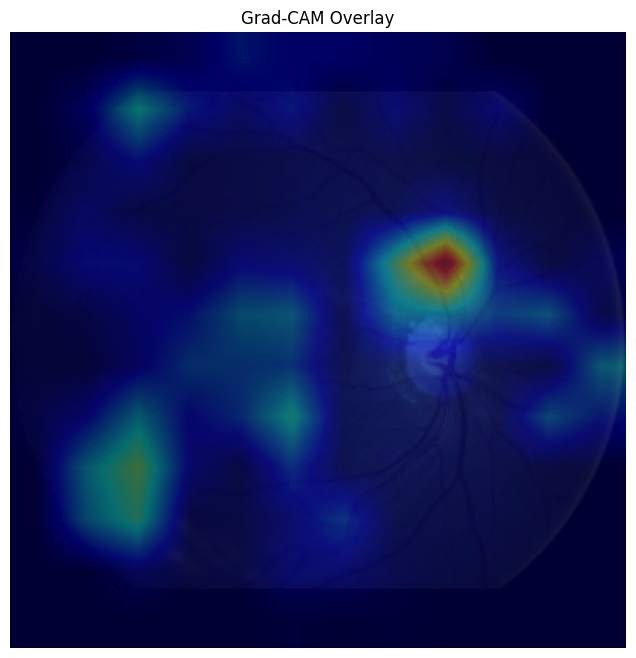

In [96]:
import cv2

heatmap_resized = cv2.resize(
    heatmap,
    (384,384)
)

heatmap_uint8 = np.uint8(
    255 * heatmap_resized
)

heatmap_color = cv2.applyColorMap(
    heatmap_uint8,
    cv2.COLORMAP_JET
)

original = img.numpy().astype(np.uint8)

overlay = cv2.addWeighted(
    original,
    0.6,
    heatmap_color,
    0.4,
    0
)

plt.figure(figsize=(8,8))
plt.imshow(
    cv2.cvtColor(
        overlay,
        cv2.COLOR_BGR2RGB
    )
)
plt.axis("off")
plt.title("Grad-CAM Overlay")
plt.show()